In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import json
import numpy as np

loc = Path.cwd()

print(loc)
json_file=[]
json_filer=[]
json_filea=[]

c:\Users\mark\OneDrive\文档\GitHub\COMP9517GROUP_SUBJECT\src\performanceCompare


In [2]:
imgNetF = loc / "resNet_data"

# Find and read all JSON files recursively
for file_path in imgNetF.rglob("*.json"):
    print(f"Found: {file_path}")
    json_filer.append(file_path)
        

imgNetA = loc / "alexnet_data"

# Find and read all JSON files recursively
for file_path in imgNetA.rglob("*.json"):
    print(f"Found: {file_path}")
    json_filea.append(file_path)
        


Found: c:\Users\mark\OneDrive\文档\GitHub\COMP9517GROUP_SUBJECT\src\performanceCompare\resNet_data\inat_resnet18_500_npclasses_imagenet_history.json
Found: c:\Users\mark\OneDrive\文档\GitHub\COMP9517GROUP_SUBJECT\src\performanceCompare\resNet_data\inat_resnet18_500_ptclasses_imagenet_history.json
Found: c:\Users\mark\OneDrive\文档\GitHub\COMP9517GROUP_SUBJECT\src\performanceCompare\resNet_data\inat_resnet50_500_npclasses_imagenet_history.json
Found: c:\Users\mark\OneDrive\文档\GitHub\COMP9517GROUP_SUBJECT\src\performanceCompare\resNet_data\inat_resnet50_500_ptclasses_imagenet_history.json
Found: c:\Users\mark\OneDrive\文档\GitHub\COMP9517GROUP_SUBJECT\src\performanceCompare\alexnet_data\inat_alexnet_500_npclasses_imagenet_history.json
Found: c:\Users\mark\OneDrive\文档\GitHub\COMP9517GROUP_SUBJECT\src\performanceCompare\alexnet_data\inat_alexnet_500_ptclasses_imagenet_history.json


In [3]:
json_file = json_filea+json_filer
json_data=[]
# Find and read all JSON files recursively
for file_path in json_file:    
    print(file_path.name)
    try:
        # read_text() reads content; json.loads() parses it
        data = json.loads(file_path.read_text(encoding="utf-8"))
        print(data)
        json_data.append(data)
        # Process your data here
    except json.JSONDecodeError:
        print(f"Error: {file_path.name} is not a valid JSON file.")

model_name={"inat_resnet18_500_ptclasses_imagenet_history.json":"ResNet18 pretrained",
            "inat_resnet50_500_ptclasses_imagenet_history.json":"ResNet50 pretrained",
            "inat_resnet18_500_npclasses_imagenet_history.json":"ResNet18 random start",
            "inat_resnet50_500_npclasses_imagenet_history.json":"ResNet50 random start",
            "inat_alexnet_500_ptclasses_imagenet_history.json": "AlexNet pretrained",
            "inat_alexnet_500_npclasses_imagenet_history.json": "AlexNet random start",
            }

json_file = json_filea +json_filer

print(len(json_file),len(model_name.keys()))
assert len(model_name.keys())==(len(json_file))

inat_alexnet_500_npclasses_imagenet_history.json
{'epoch': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33], 'train_loss': [6.1704387306213375, 5.982462158203125, 5.786348413085937, 5.595894142913818, 5.455192259979248, 5.306570293426514, 5.151204435729981, 4.988171231842041, 4.82398828048706, 4.6686056644439695, 4.5108611801147465, 4.345543841934204, 4.180945719528198, 4.011891952133179, 3.83704907951355, 3.6520345615386964, 3.462300033569336, 3.2667587696075437, 3.0870065223693848, 2.69447331161499, 2.5500748611450197, 2.4360231735229494, 2.3168412353515624, 2.135865026473999, 2.0682939449310305, 2.0272244438171385, 1.975235601234436, 1.9361739469528199, 1.896732075881958, 1.8170907726287842, 1.795148969078064, 1.7741652740478515, 1.7407337451934815], 'train_accuracy': [0.0027, 0.00415, 0.01265, 0.0239, 0.03245, 0.0487, 0.06425, 0.0833, 0.10205, 0.1246, 0.1429, 0.17135, 0.2004, 0.2286, 0.2645, 0.3037, 0.34985,

In [4]:
print("json_data:", len(json_data))
print("json_file:", len(json_file))
print("model_name:", len(model_name))

json_data: 6
json_file: 6
model_name: 6


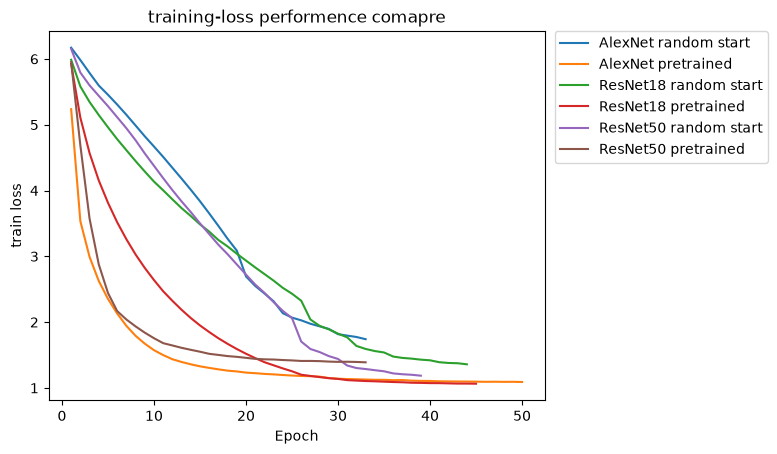

In [5]:
# train loss

for dt in range(len(json_data)):
    plt.plot(json_data[dt]['epoch'], json_data[dt]['train_loss'], label=model_name[json_file[dt].name], linestyle="-")

    
# # Add a legend, labels, and show the plot
plt.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    borderaxespad=0
)
plt.xlabel("Epoch")
plt.ylabel("train loss")
plt.title("training-loss performence comapre")
plt.show()



# https://stackoverflow.com/questions/16006572/plotting-different-colors-in-matplotlib

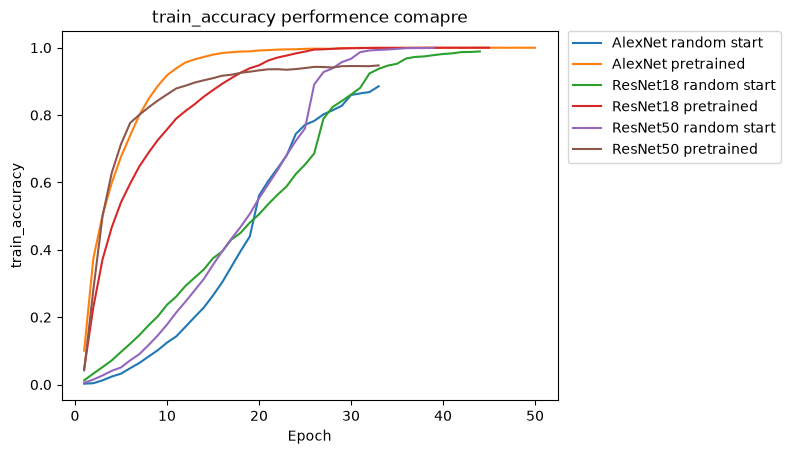

In [6]:
# train acc

for dt in range(len(json_data)):
    plt.plot(json_data[dt]['epoch'], json_data[dt]['train_accuracy'], label=model_name[json_file[dt].name], linestyle="-")

    
# # Add a legend, labels, and show the plot
plt.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    borderaxespad=0
)
plt.xlabel("Epoch")
plt.ylabel("train_accuracy")
plt.title("train_accuracy performence comapre")
plt.show()



# https://stackoverflow.com/questions/16006572/plotting-different-colors-in-matplotlib

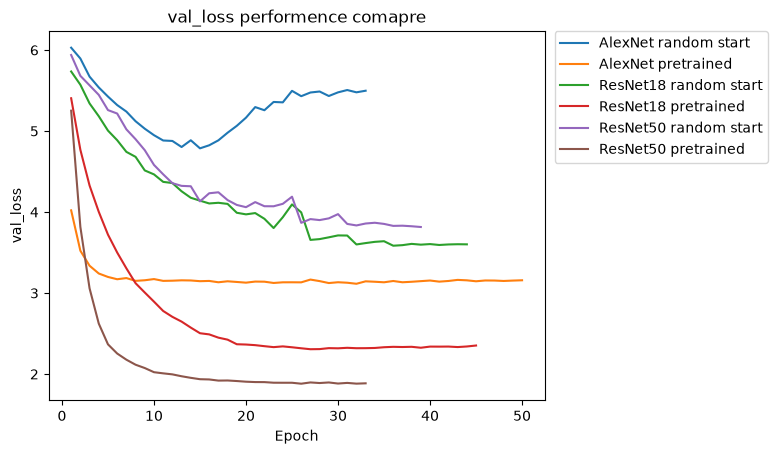

In [7]:
# val loss


for dt in range(len(json_data)):
    plt.plot(json_data[dt]['epoch'], json_data[dt]['val_loss'], label=model_name[json_file[dt].name], linestyle="-")

    
# # Add a legend, labels, and show the plot
plt.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    borderaxespad=0
)
plt.xlabel("Epoch")
plt.ylabel("val_loss")
plt.title("val_loss performence comapre")
plt.show()



# https://stackoverflow.com/questions/16006572/plotting-different-colors-in-matplotlib

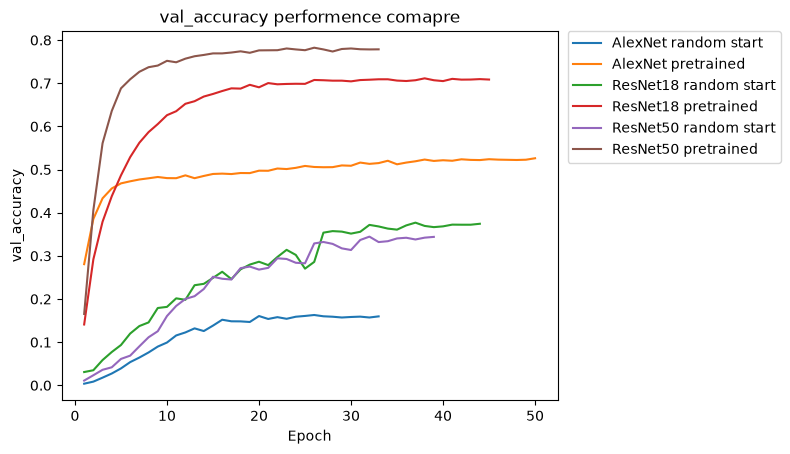

In [ ]:
# train acc


for dt in range(len(json_data)):
    plt.plot(json_data[dt]['epoch'], json_data[dt]['val_accuracy'], label=model_name[json_file[dt].name], linestyle="-")

    
# # Add a legend, labels, and show the plot
plt.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    borderaxespad=0
)
plt.xlabel("Epoch")
plt.ylabel("val accuracy")
plt.title("val accuracy performence comapre")
plt.show()



# https://stackoverflow.com/questions/16006572/plotting-different-colors-in-matplotlib

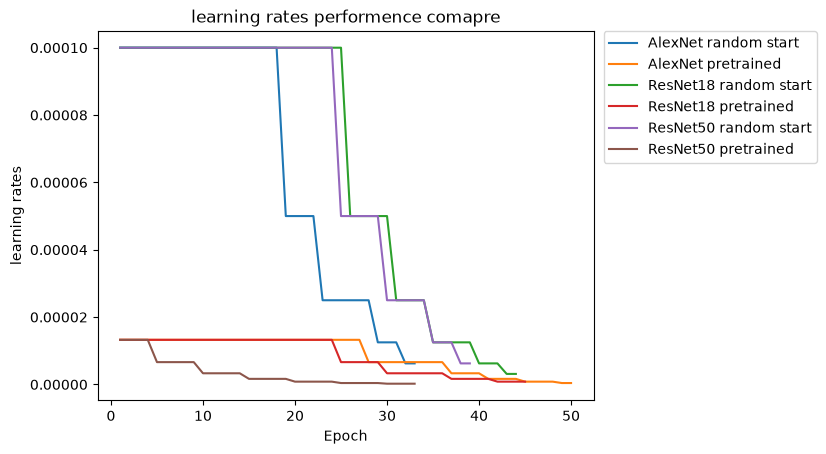

In [10]:
# learning rate

for dt in range(len(json_data)):
    if type(json_data[dt]['learning_rates'][0]) == list:
        row_averages = [sum(row) / len(row) for row in json_data[dt]['learning_rates']]
        plt.plot(json_data[dt]['epoch'], row_averages, label=model_name[json_file[dt].name], linestyle="-")

    else:
        plt.plot(json_data[dt]['epoch'], json_data[dt]['learning_rates'], label=model_name[json_file[dt].name], linestyle="-")

    
# # Add a legend, labels, and show the plot
plt.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    borderaxespad=0
)
plt.xlabel("Epoch")
plt.ylabel("learning rates")
plt.title("learning rates performence comapre")

plt.show()



# https://stackoverflow.com/questions/16006572/plotting-different-colors-in-matplotlib